In [ ]:
import zipfile
import os
import cv2

zip_path = "/content/archive (21) (2).zip"
extract_path = "extracted1_images"

# Extract the ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Read all images
images = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)

            if img is not None:
                images.append(img)


### Data Preparation

Now that the images are extracted, we need to prepare them for our Convolutional Neural Network (CNN). This involves:

1.  **Labeling**: Assigning a label (e.g., 'yes' for tumor, 'no' for no tumor) to each image based on its directory.
2.  **Resizing**: Ensuring all images have a consistent size.
3.  **Normalization**: Scaling pixel values to a common range (e.g., 0-1).
4.  **Splitting**: Dividing the dataset into training and testing sets to evaluate the model's performance.

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [ ]:
# Initialize lists to store images and labels
data = []
labels = []

# Define image size for resizing
IMG_SIZE = 128

# Assuming the structure is extracted_images/brain_tumor_dataset/yes/image.jpg and extracted_images/brain_tumor_dataset/no/image.jpg
# We need to explicitly define the paths to 'yes' and 'no' folders if the `os.walk` was too broad

# Let's verify the `extract_path` and construct the paths for 'yes' and 'no'
yes_path = os.path.join(extract_path, 'brain_tumor_dataset', 'yes')
no_path = os.path.join(extract_path, 'brain_tumor_dataset', 'no')

# Function to load images and assign labels
def load_images_from_folder(folder, label):
    count = 0
    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)
        try:
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) # Resize image
                data.append(img)
                labels.append(label)
                count += 1
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
    print(f"Loaded {count} images from {folder}")


print(f"Loading 'yes' images from: {yes_path}")
load_images_from_folder(yes_path, 1) # Label 1 for 'yes' (tumor)

print(f"Loading 'no' images from: {no_path}")
load_images_from_folder(no_path, 0) # Label 0 for 'no' (no tumor)


# Convert lists to numpy arrays
data = np.array(data)
labels = np.array(labels)

print(f"Total images loaded: {len(data)}")
print(f"Shape of data array: {data.shape}")
print(f"Shape of labels array: {labels.shape}")

Loading 'yes' images from: extracted1_images/brain_tumor_dataset/yes
Loaded 155 images from extracted1_images/brain_tumor_dataset/yes
Loading 'no' images from: extracted1_images/brain_tumor_dataset/no
Loaded 98 images from extracted1_images/brain_tumor_dataset/no
Total images loaded: 253
Shape of data array: (253, 128, 128, 3)
Shape of labels array: (253,)


In [ ]:
# Normalize pixel values to be between 0 and 1
data = data / 255.0

# Convert labels to one-hot encoding for categorical crossentropy loss
labels = to_categorical(labels, num_classes=2)

print("Data normalized and labels one-hot encoded.")
print(f"Shape of normalized data: {data.shape}")
print(f"Shape of one-hot encoded labels: {labels.shape}")

Data normalized and labels one-hot encoded.
Shape of normalized data: (253, 128, 128, 3)
Shape of one-hot encoded labels: (253, 2)


Let's visualize a few preprocessed images to ensure everything looks correct.

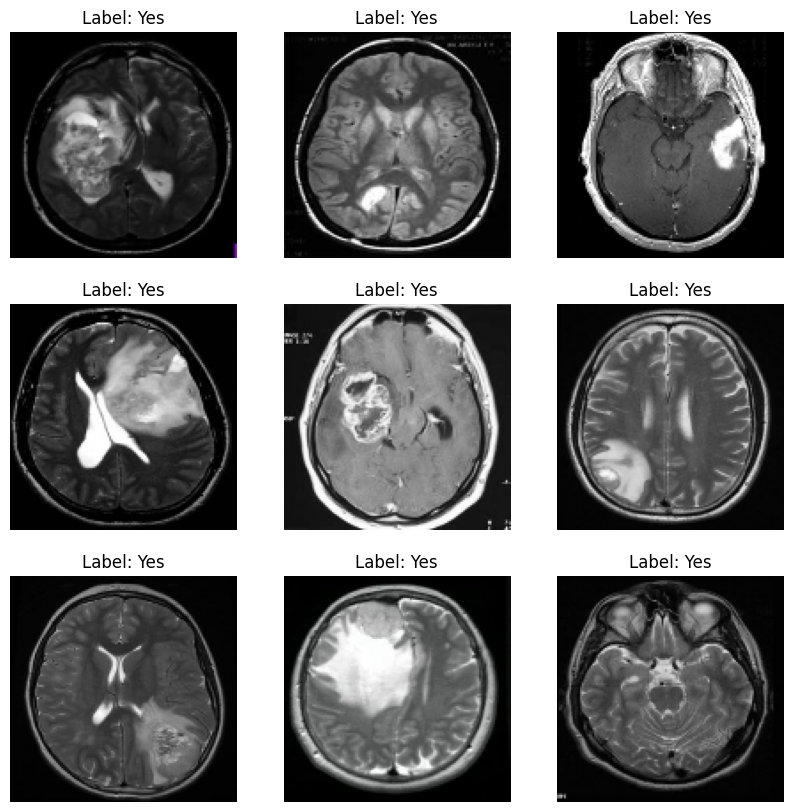

In [ ]:
plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(data[i])
    plt.title(f"Label: {'Yes' if np.argmax(labels[i]) == 1 else 'No'}")
    plt.axis("off")
plt.show()

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    data,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(labels, axis=1)
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (202, 128, 128, 3)
X_test shape: (51, 128, 128, 3)
y_train shape: (202, 2)
y_test shape: (51, 2)


### Building the CNN Model

Now we will define the architecture of our Convolutional Neural Network (CNN). A typical CNN for image classification includes:

1.  **Convolutional Layers (`Conv2D`)**: To extract features from the images.
2.  **Activation Functions**: Like `ReLU` to introduce non-linearity.
3.  **Pooling Layers (`MaxPooling2D`)**: To reduce spatial dimensions and make the model more robust to variations.
4.  **Flatten Layer**: To convert the 2D feature maps into a 1D vector.
5.  **Dense Layers (`Dense`)**: Fully connected layers for classification.
6.  **Dropout Layers (`Dropout`)**: To prevent overfitting.

After defining the architecture, we will compile the model by specifying an optimizer, a loss function, and evaluation metrics.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


In [ ]:
# Define the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dropout(0.5), # Add dropout for regularization
    Dense(128, activation='relu'),
    Dropout(0.5), # Add dropout for regularization
    Dense(2, activation='softmax') # 2 classes: 'yes' (tumor) or 'no' (no tumor)
])

# Compile the model
model.compile(optimizer='adam', # Adam optimizer is a good default choice
              loss='categorical_crossentropy', # Appropriate for one-hot encoded labels
              metrics=['accuracy']) # Monitor accuracy during training

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,898 (12.61 MB)

 Trainable params: 3,304,898 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

### Building the CNN Model

Now we will define the architecture of our Convolutional Neural Network (CNN). A typical CNN for image classification includes:

1.  **Convolutional Layers (`Conv2D`)**: To extract features from the images.
2.  **Activation Functions**: Like `ReLU` to introduce non-linearity.
3.  **Pooling Layers (`MaxPooling2D`)**: To reduce spatial dimensions and make the model more robust to variations.
4.  **Flatten Layer**: To convert the 2D feature maps into a 1D vector.
5.  **Dense Layers (`Dense`)**: Fully connected layers for classification.
6.  **Dropout Layers (`Dropout`)**: To prevent overfitting.

After defining the architecture, we will compile the model by specifying an optimizer, a loss function, and evaluation metrics.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


In [ ]:
# Define the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dropout(0.5), # Add dropout for regularization
    Dense(128, activation='relu'),
    Dropout(0.5), # Add dropout for regularization
    Dense(2, activation='softmax') # 2 classes: 'yes' (tumor) or 'no' (no tumor)
])

# Compile the model
model.compile(optimizer='adam', # Adam optimizer is a good default choice
              loss='categorical_crossentropy', # Appropriate for one-hot encoded labels
              metrics=['accuracy']) # Monitor accuracy during training

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,898 (12.61 MB)

 Trainable params: 3,304,898 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

### Training the CNN Model

Now we will train the CNN model using the `fit` method. During training, the model will learn from the `X_train` and `y_train` data. We will also monitor its performance on the `X_test` and `y_test` data as a validation set to check for overfitting and evaluate how well it generalizes to unseen data.

We will specify:
- `epochs`: The number of times the model will go through the entire training dataset.
- `batch_size`: The number of samples per gradient update.
- `validation_data`: The data to be used for validation.

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20, # You can adjust the number of epochs
    batch_size=32, # You can adjust the batch size
    validation_data=(X_test, y_test)
)

print("Model training complete.")

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 848ms/step - accuracy: 0.5990 - loss: 0.6769 - val_accuracy: 0.8235 - val_loss: 0.5312
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.7970 - loss: 0.5222 - val_accuracy: 0.8431 - val_loss: 0.4930
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.7822 - loss: 0.5192 - val_accuracy: 0.8431 - val_loss: 0.4430
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 814ms/step - accuracy: 0.7921 - loss: 0.4829 - val_accuracy: 0.8627 - val_loss: 0.4349
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 767ms/step - accuracy: 0.7970 - loss: 0.4508 - val_accuracy: 0.8627 - val_loss: 0.4160
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 999ms/step - accuracy: 0.7921 - loss: 0.4313 - val_accuracy: 0.8824 - val_loss: 0.4175
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 772ms/step - accuracy: 0.8515 - loss: 0.3799 - val_accuracy: 0.8235 - val_loss: 0.3943
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8465 - loss: 0.3145 - val_accuracy: 0.8431 - val_loss: 0.34

### Model Evaluation and Visualization

After training, it's crucial to evaluate the model's performance and visualize the training process. This helps in understanding:

1.  **Overfitting/Underfitting**: By comparing training and validation metrics.
2.  **Convergence**: How well the model learned over epochs.

We will plot the training and validation accuracy and loss curves. Finally, we will evaluate the model's performance on the test dataset (`X_test`, `y_test`).

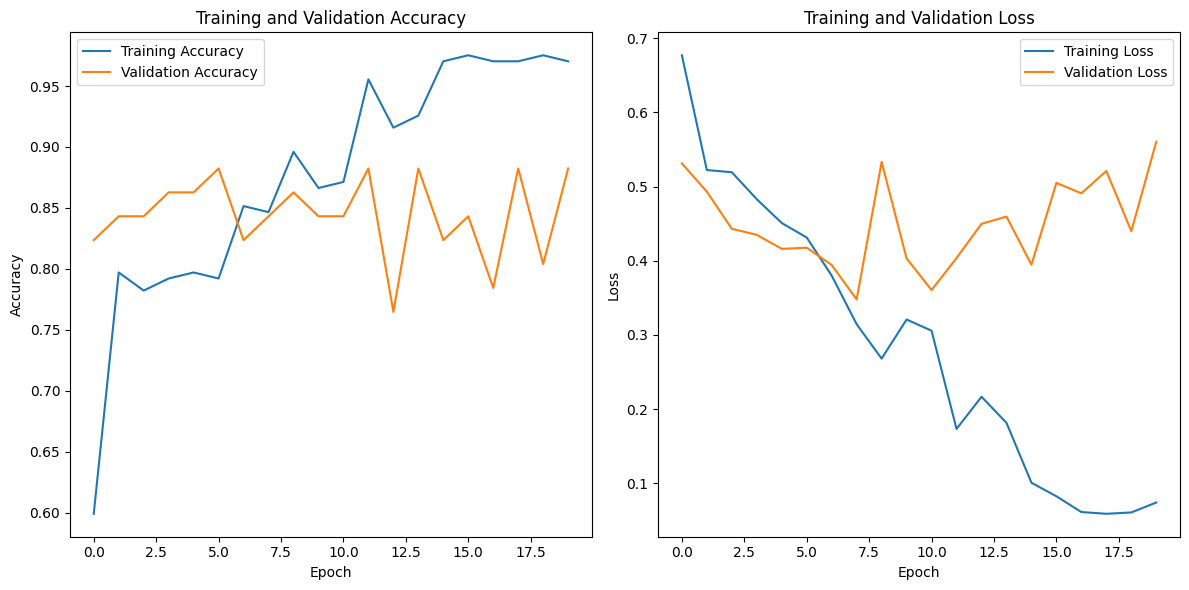

In [ ]:
# Plot training and validation accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 0.5603
Test Accuracy: 0.8824


### Visualize Predictions

To better understand the model's performance, let's visualize a few test images and their corresponding predictions. This will show us where the model succeeded and where it might have made errors.

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Convert predictions and true labels from one-hot encoding to single class labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

print("Predictions made.")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 195ms/step
Predictions made.


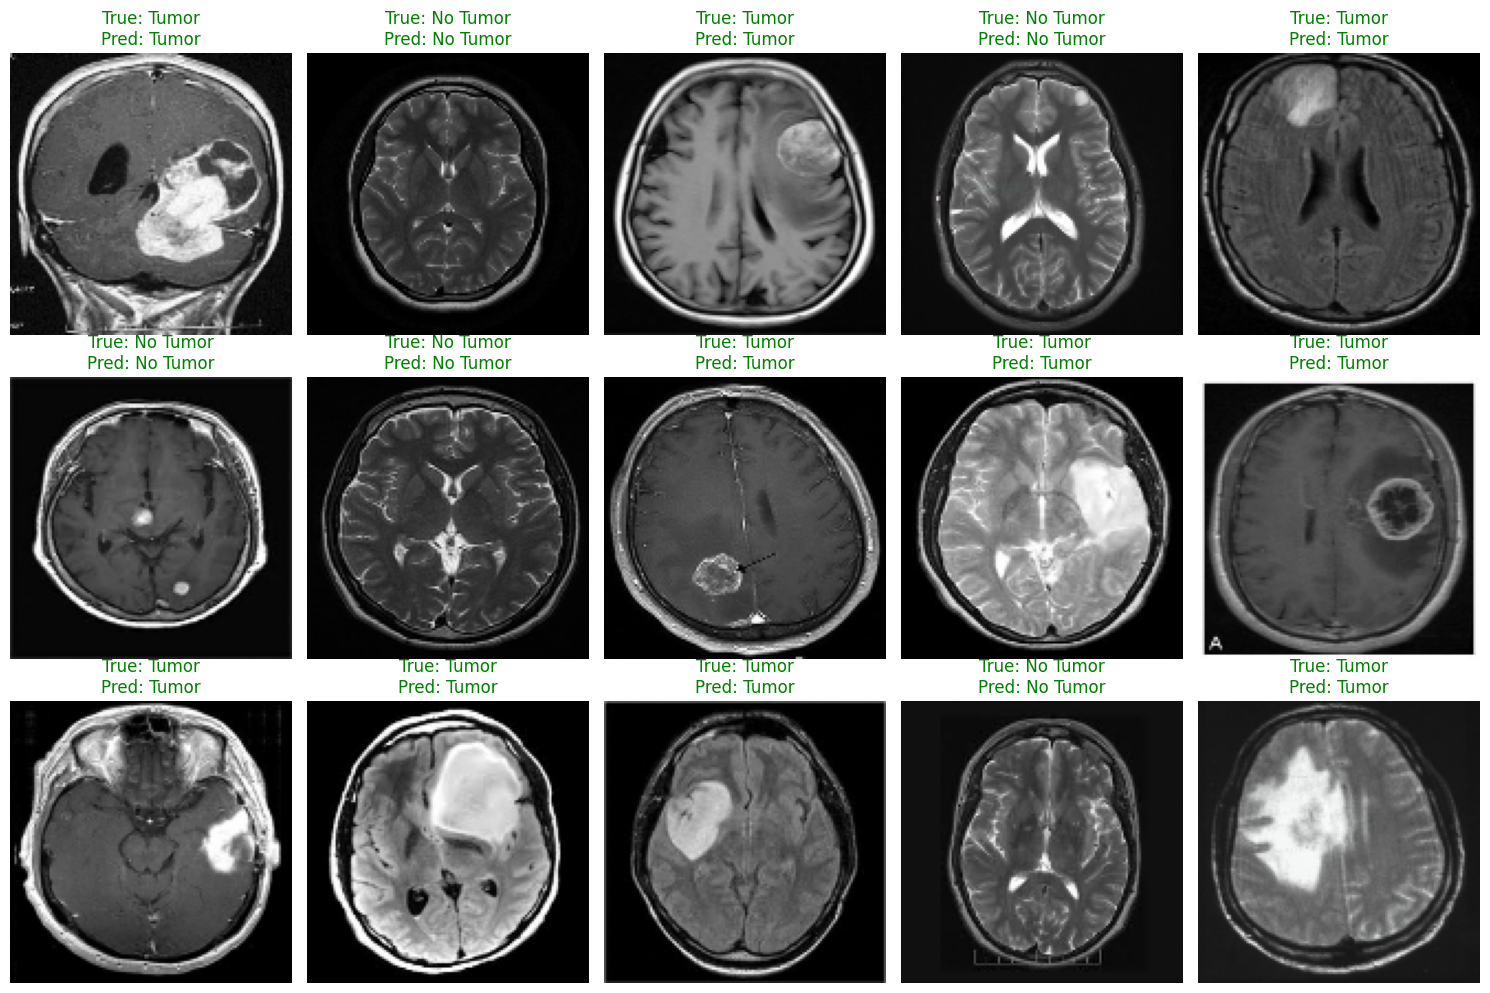

In [ ]:
# Display a few test images with their true and predicted labels
plt.figure(figsize=(15, 10))
for i in range(15): # Display 15 images
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test[i])

    true_label = 'Tumor' if y_test_classes[i] == 1 else 'No Tumor'
    pred_label = 'Tumor' if y_pred_classes[i] == 1 else 'No Tumor'

    color = "green" if true_label == pred_label else "red"
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()